Available files in environment:
['outputs', 'da_sample_guest_profiles.csv', 'notebook.ipynb', 'da_sample_stay_details.csv', 'final_clean_dataset.csv', 'da_sample_ancillary_spend.csv']

Using files:
Guest profiles: da_sample_guest_profiles.csv
Stay details: da_sample_stay_details.csv
Ancillary spend: da_sample_ancillary_spend.csv

Data loaded successfully ✅

===== VALIDATION: GUEST_PROFILES =====
Shape: (400, 3)

Columns:
['guest_id', 'loyalty_tier', 'marketing_consent']

Data types:
guest_id              int64
loyalty_tier         object
marketing_consent      bool
dtype: object

Missing values:
guest_id               0
loyalty_tier         193
marketing_consent      0
dtype: int64

Duplicate rows: 0

Preview:
   guest_id loyalty_tier  marketing_consent
0         1          NaN               True
1         2     Platinum              False
2         3       Silver               True
3         4       Silver              False
4         5          NaN               True

===== VALIDATIO

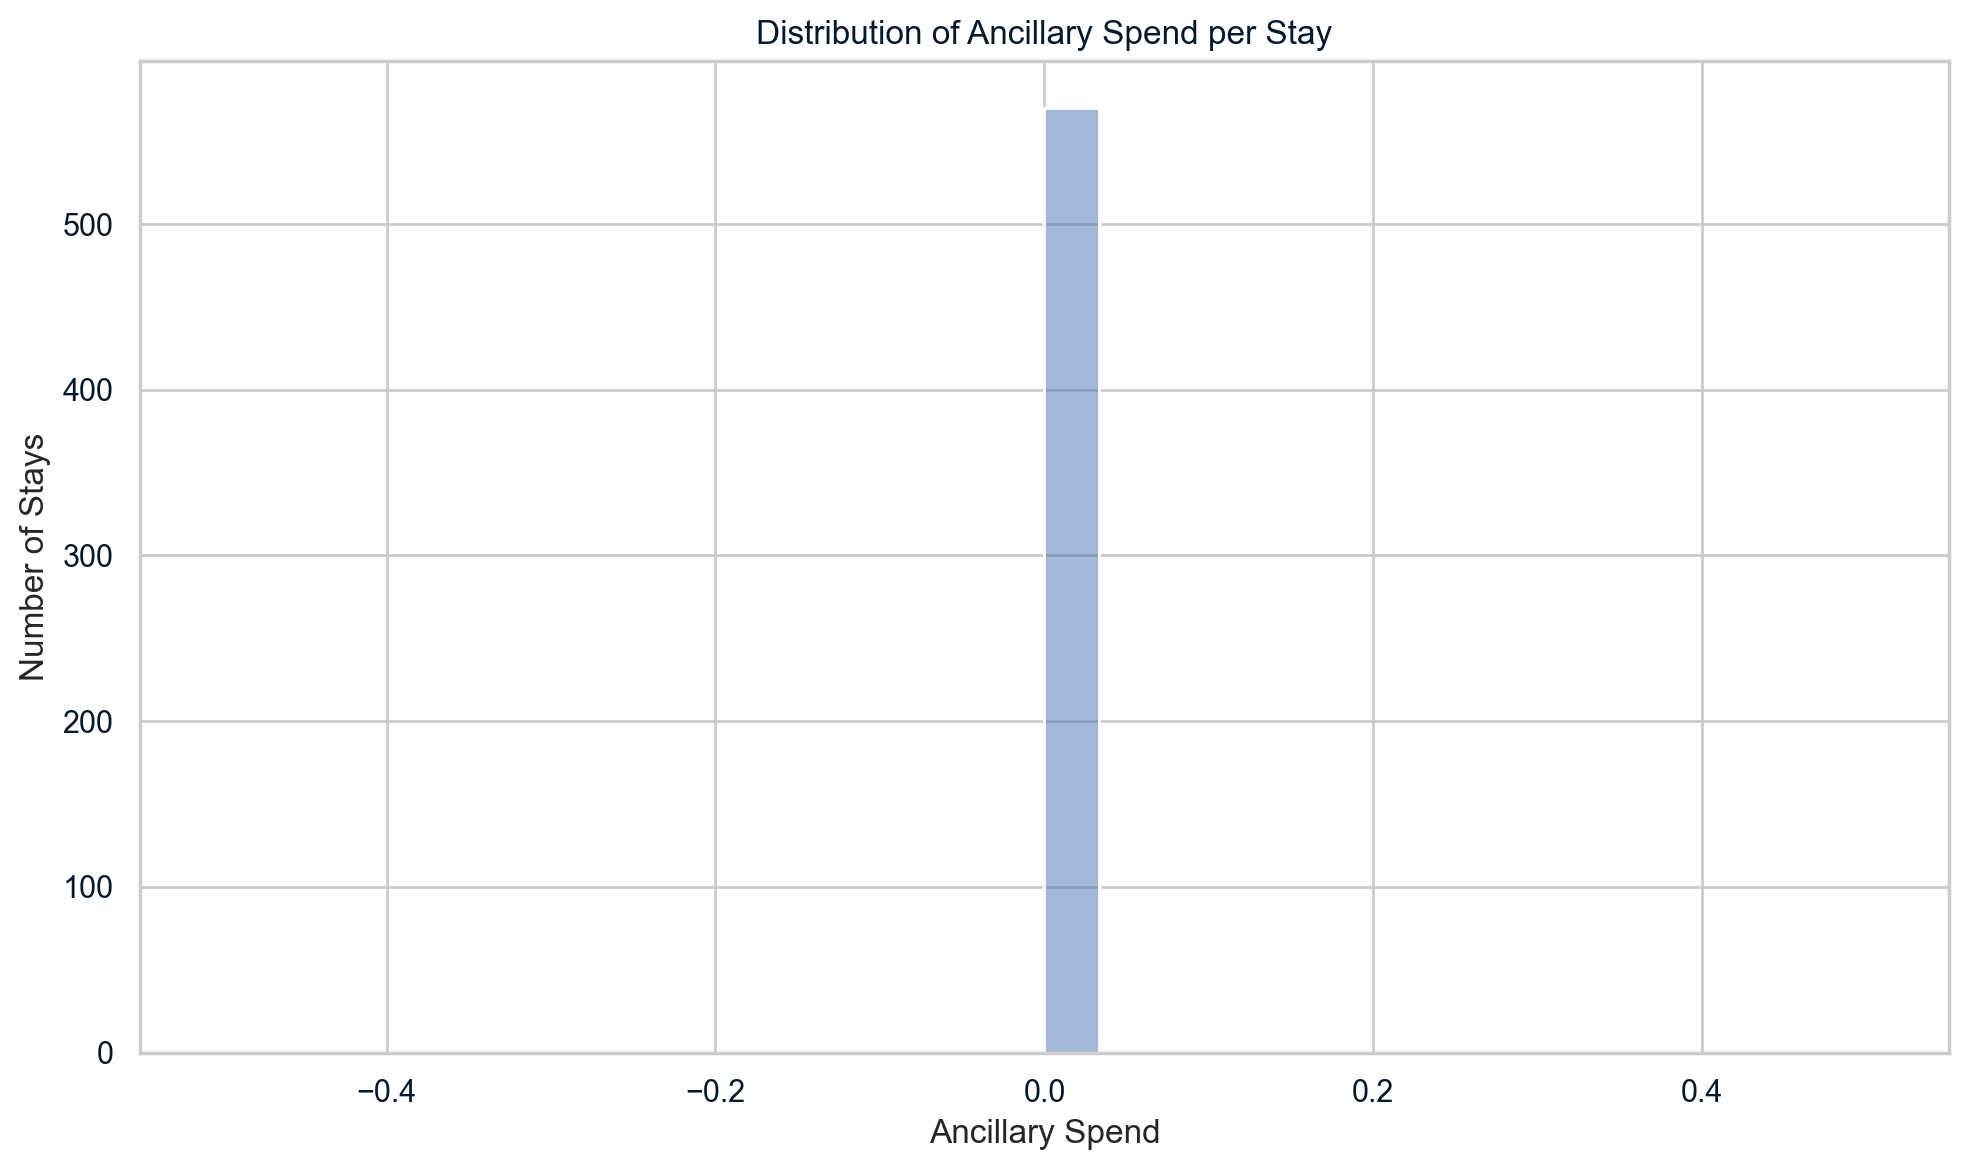

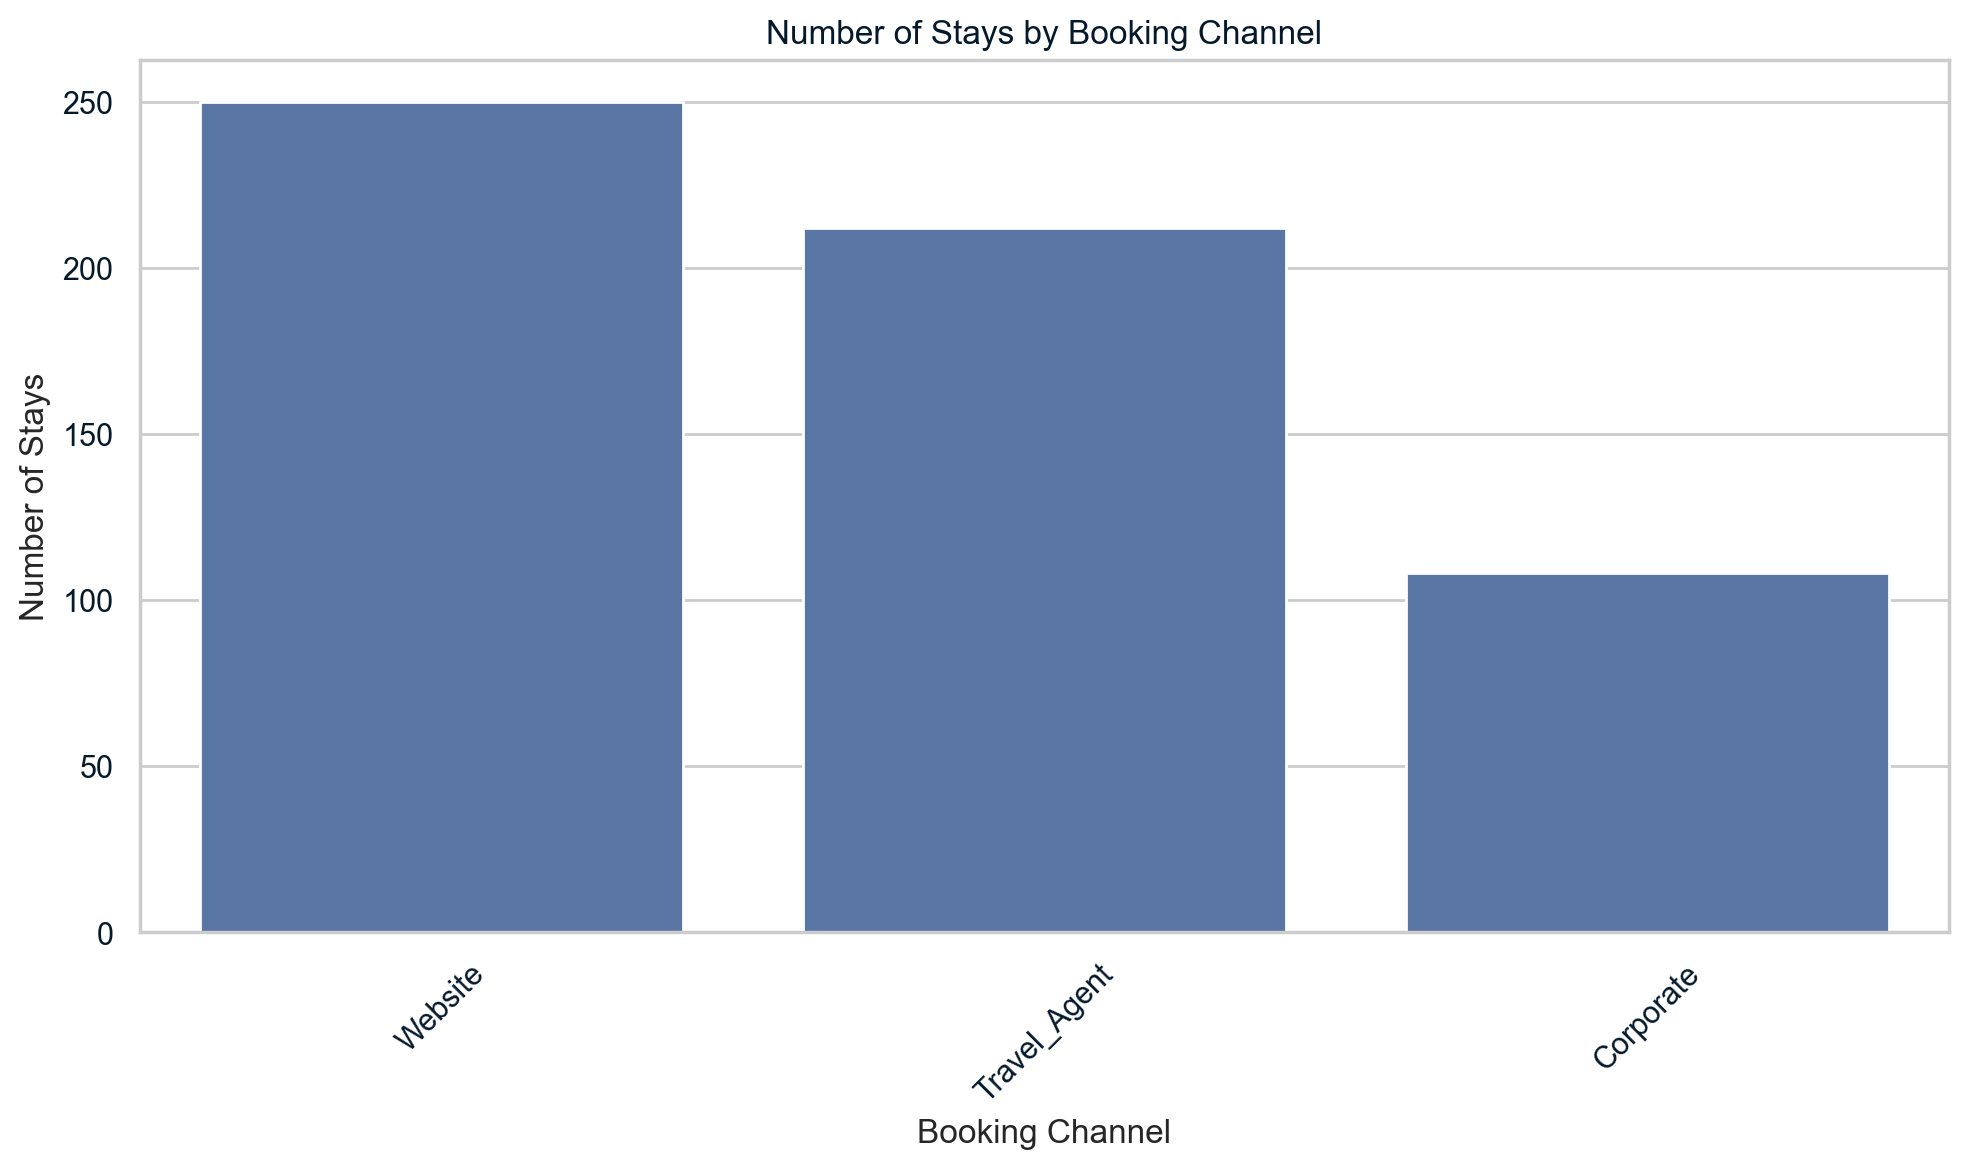

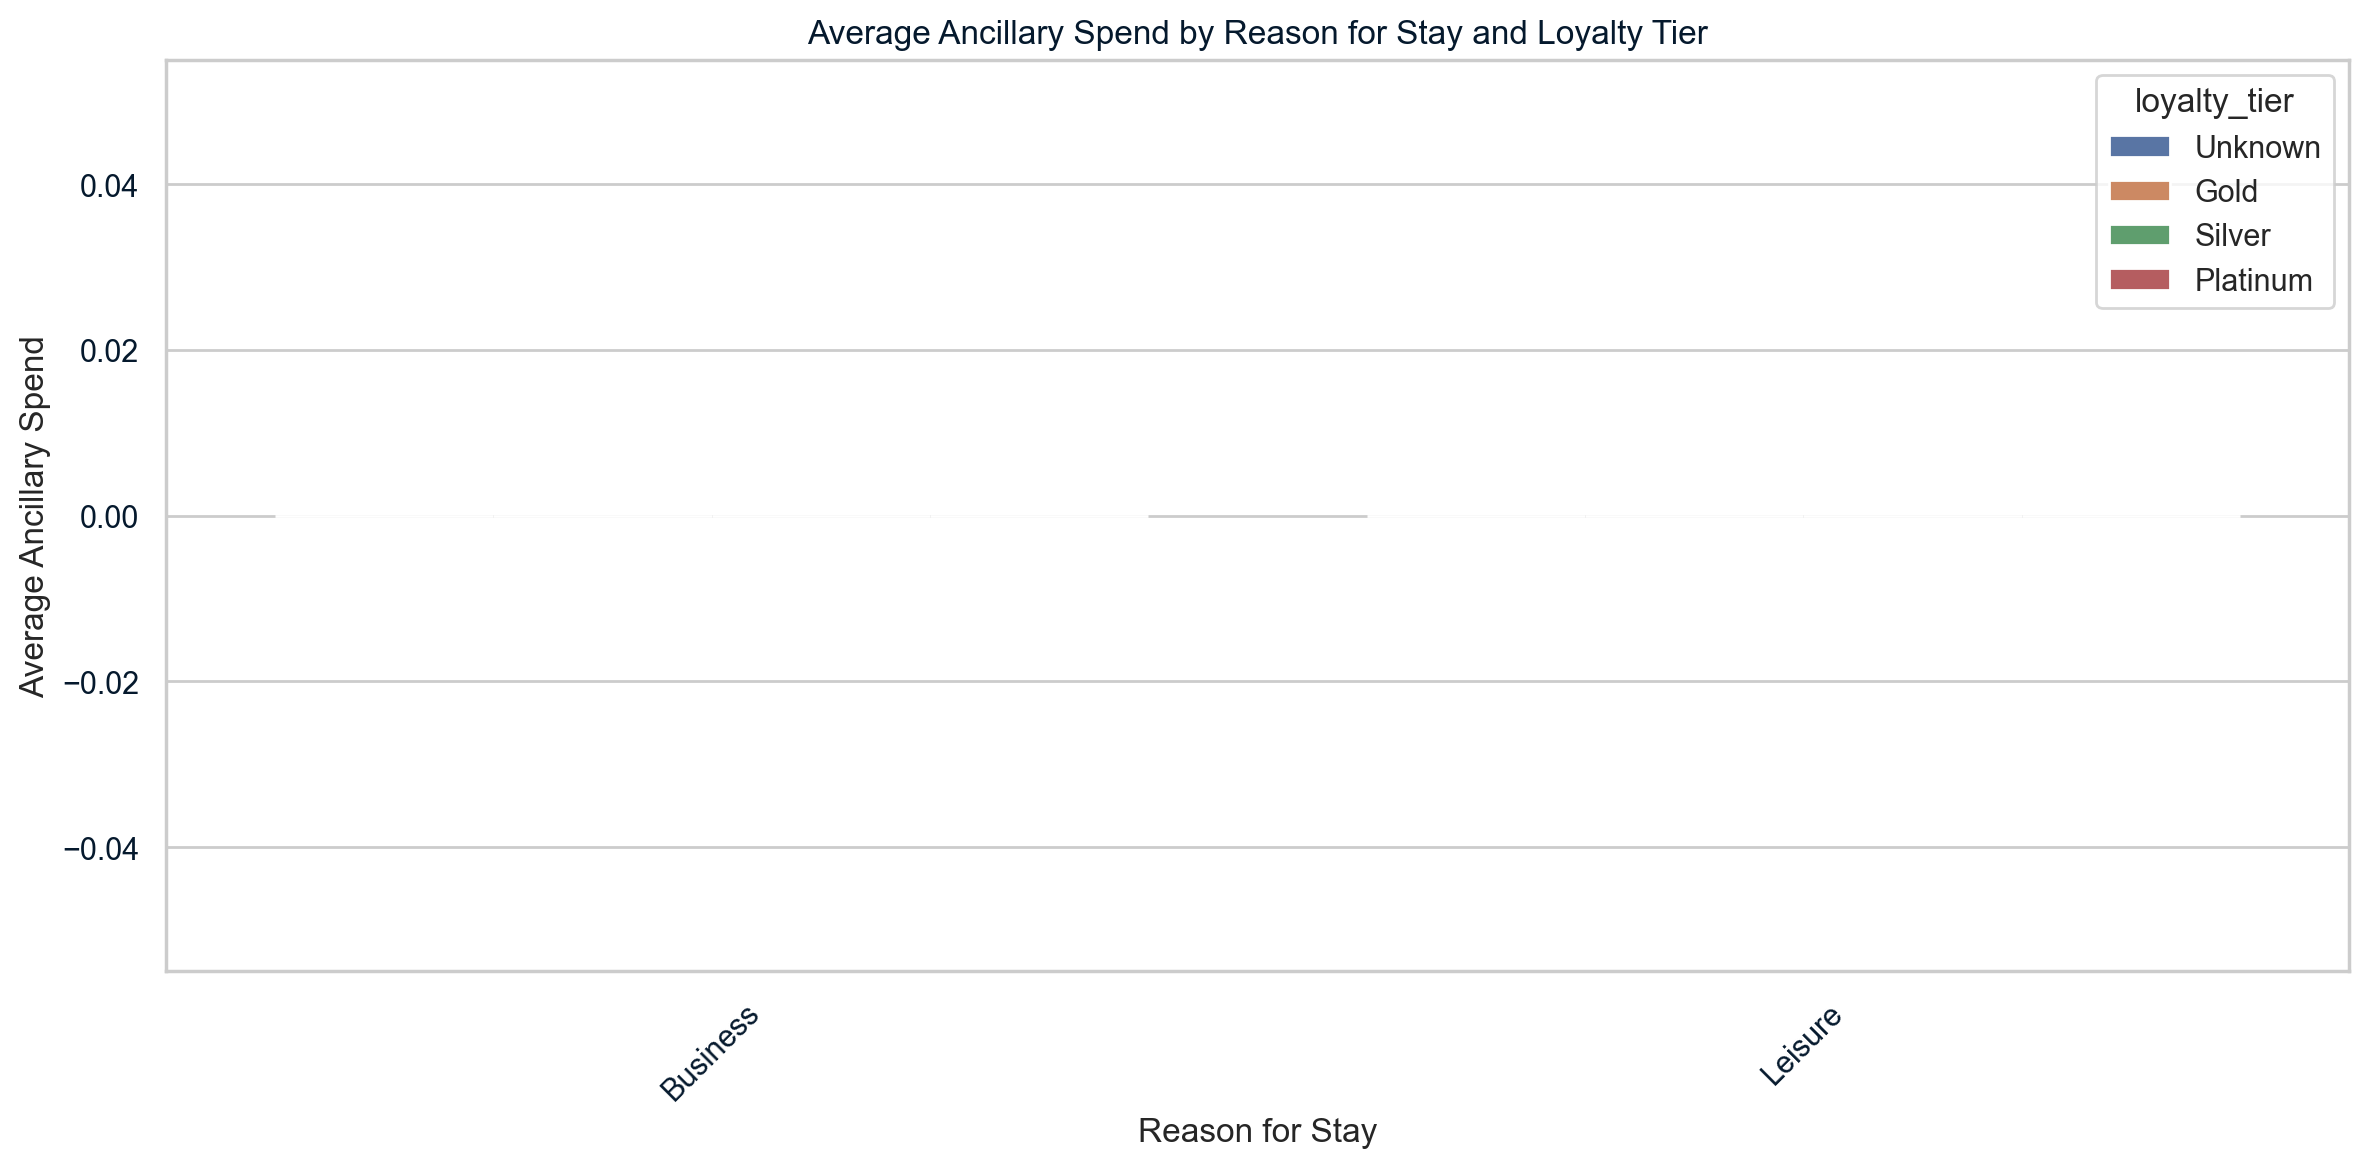

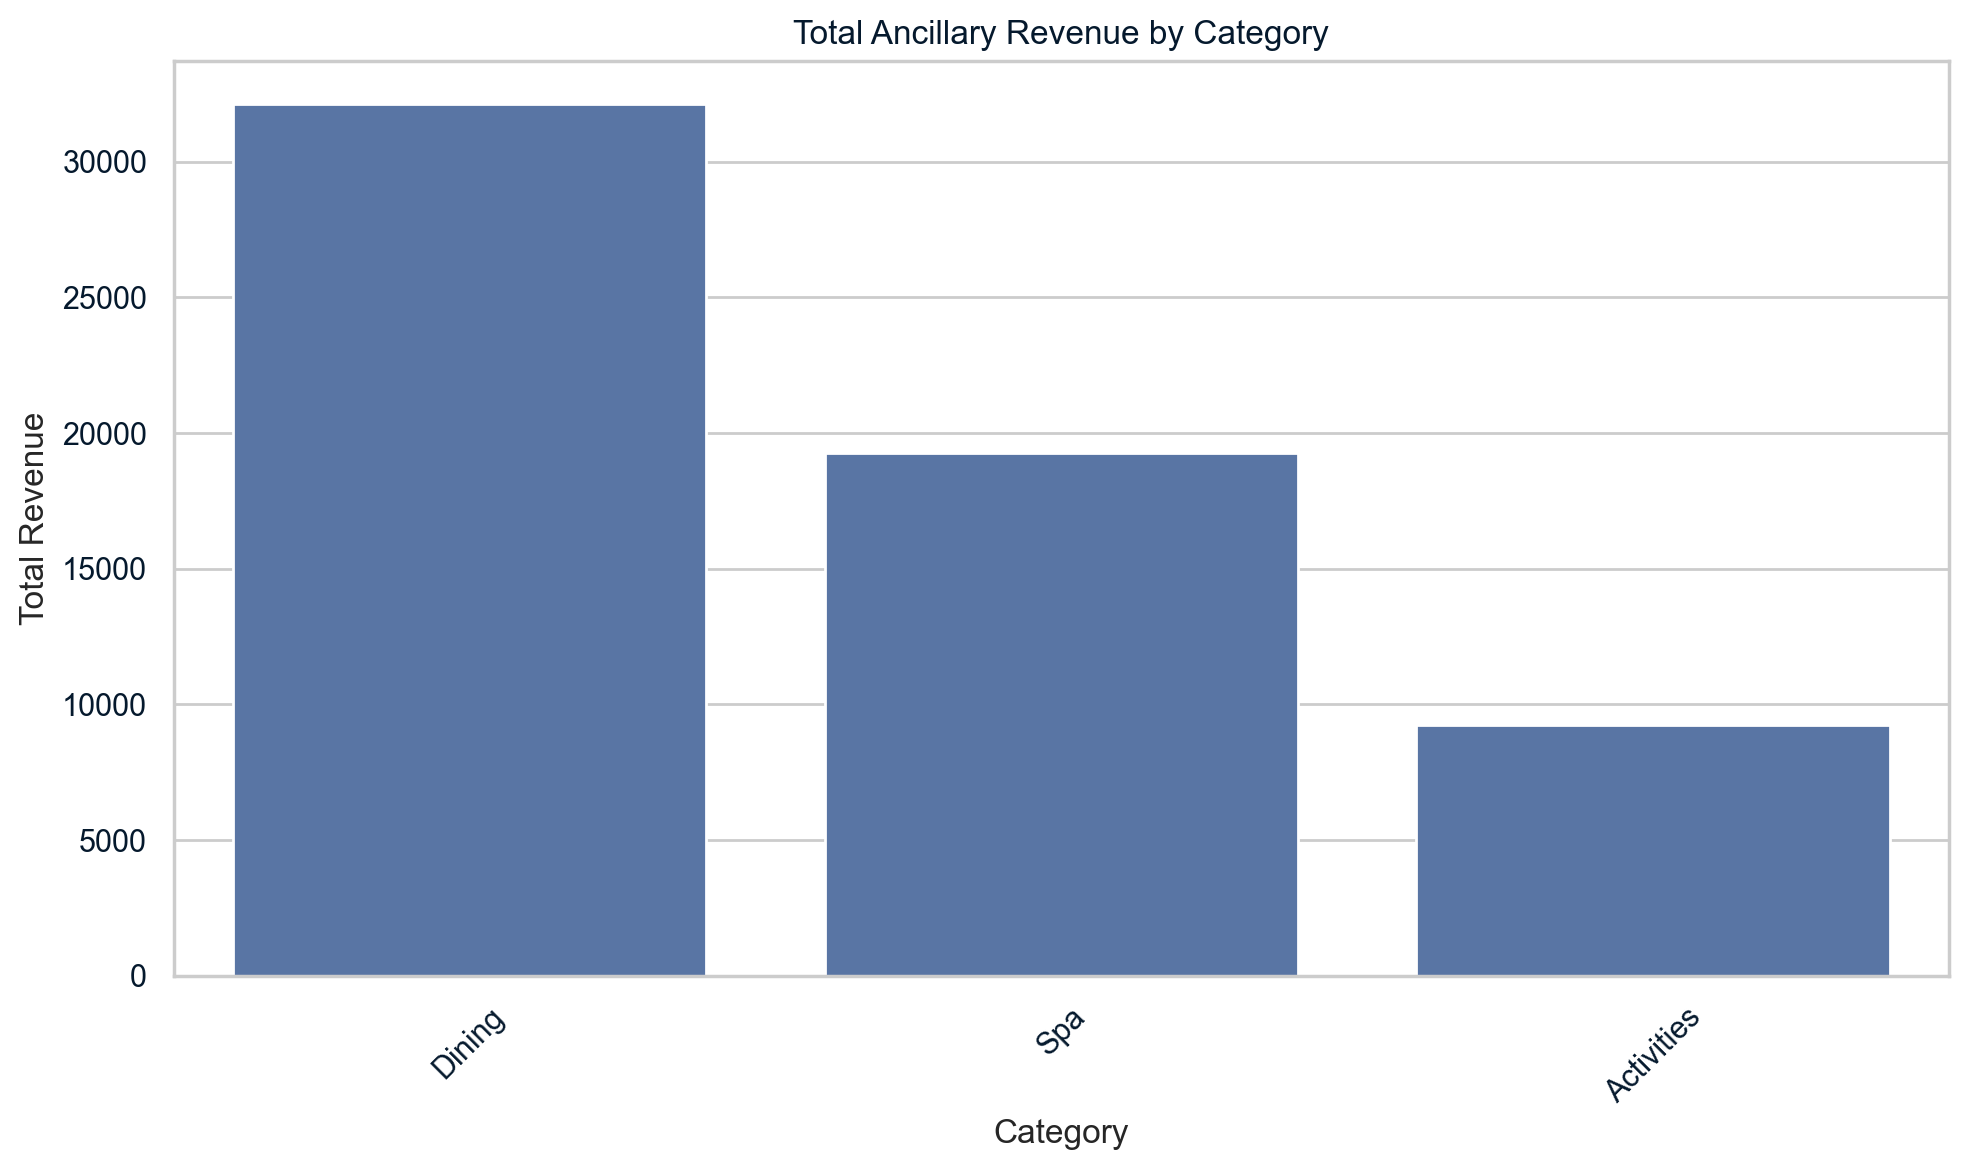

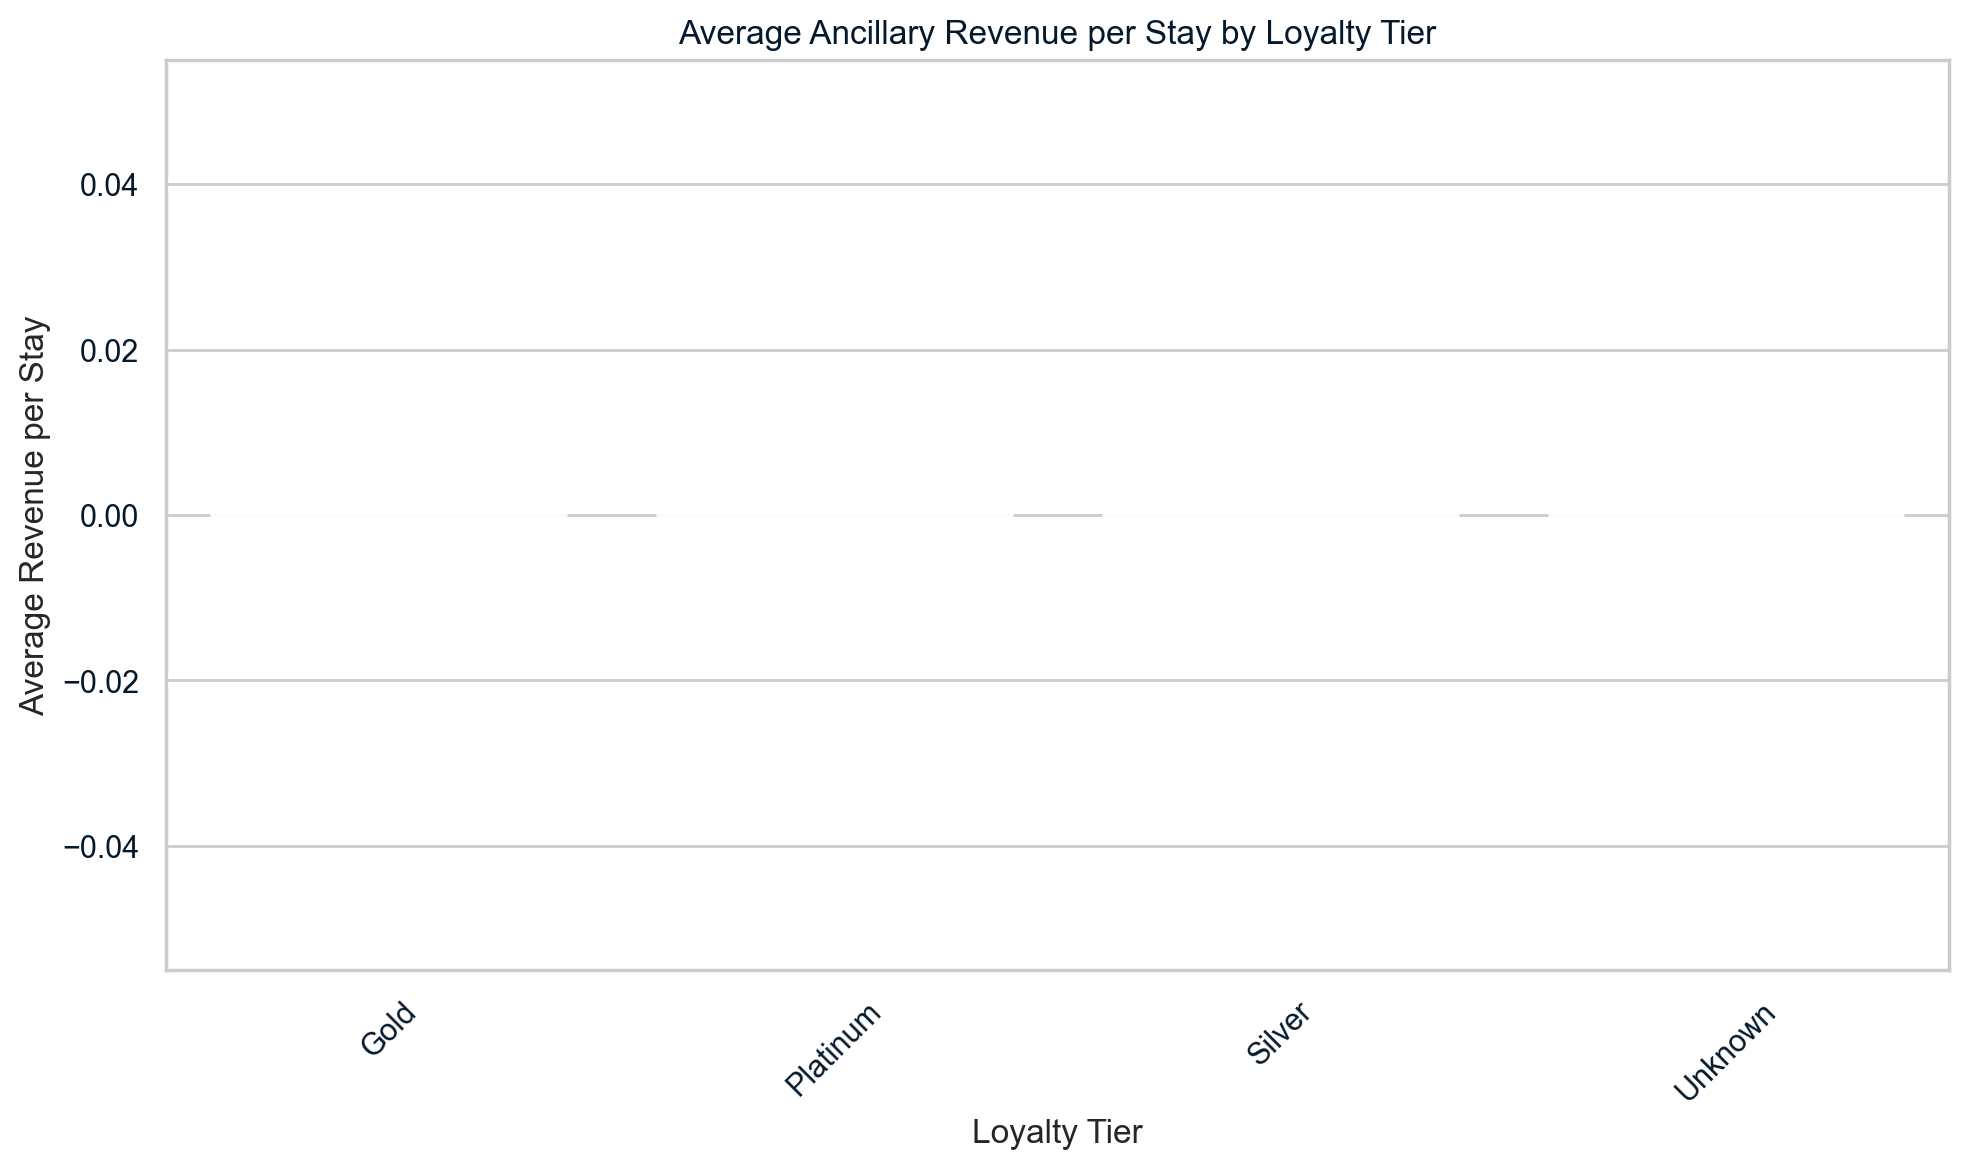


All outputs saved in the 'outputs' folder ✅

===== REPORT / PRESENTATION STARTER INSIGHTS =====

Primary KPI:
Average Ancillary Revenue per Stay = 0.00

Supporting Metrics:
Total Ancillary Revenue = 0.00
Ancillary Conversion Rate = 0.00%
Average Spend per Guest = 0.00

Highest Revenue Loyalty Segment:
Gold

Highest Revenue Reason for Stay:
Business

Highest Revenue Booking Channel:
Corporate

Highest Revenue Ancillary Category:
Dining

Recommended Business Actions:
1. Prioritize offers toward the highest-spending guest segments.
2. Promote the strongest ancillary category more aggressively during booking and check-in.
3. Target guests with low conversion but high stay volume using bundled offers.
4. Use Average Ancillary Revenue per Stay as the main KPI and track it daily or weekly.
5. Compare performance by loyalty tier, booking channel, and reason for stay to identify revenue gaps.



In [1]:
# SOLSTICE OPAL HOTEL
# ANCILLARY REVENUE ANALYSIS

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. AUTO-DETECT FILES

print("Available files in environment:")
files = os.listdir()
print(files)


def find_file(keyword):
    for f in files:
        if keyword in f.lower() and f.lower().endswith(".csv"):
            return f
    return None


guest_file = find_file("guest")
stay_file = find_file("stay")
ancillary_file = find_file("ancillary")

if not guest_file or not stay_file or not ancillary_file:
    raise FileNotFoundError(
        f"""
Could not find all required CSV files.

Detected:
Guest file: {guest_file}
Stay file: {stay_file}
Ancillary file: {ancillary_file}

Check that the three CSV files are uploaded and have names containing:
guest, stay, and ancillary.
"""
    )

print("\nUsing files:")
print("Guest profiles:", guest_file)
print("Stay details:", stay_file)
print("Ancillary spend:", ancillary_file)

# 2. LOAD DATA SAFELY

guest_profiles = pd.read_csv(guest_file)
stay_details = pd.read_csv(stay_file)
ancillary_spend = pd.read_csv(ancillary_file)

print("\nData loaded successfully ✅")

# 3. DATA VALIDATION BEFORE CLEANING

def validate_data(df, name):
    print(f"\n===== VALIDATION: {name.upper()} =====")
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nData types:")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isna().sum())
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nPreview:")
    print(df.head())


validate_data(guest_profiles, "guest_profiles")
validate_data(stay_details, "stay_details")
validate_data(ancillary_spend, "ancillary_spend")

# 4. STANDARDIZE COLUMN NAMES

for df_temp in [guest_profiles, stay_details, ancillary_spend]:
    df_temp.columns = df_temp.columns.str.strip().str.lower()

# In case Guest_id appears with capital G, this is now fixed to guest_id after lowercasing.

# 5. CLEAN GUEST PROFILES

guest_profiles["guest_id"] = guest_profiles["guest_id"].astype(str).str.strip()

guest_profiles["loyalty_tier"] = (
    guest_profiles["loyalty_tier"]
    .astype(str)
    .str.strip()
    .str.title()
    .replace(["Nan", "None", "", "Null"], np.nan)
)

guest_profiles["marketing_consent"] = (
    guest_profiles["marketing_consent"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "true": True,
        "false": False,
        "yes": True,
        "no": False,
        "y": True,
        "n": False,
        "1": True,
        "0": False
    })
)

guest_profiles["loyalty_tier"] = guest_profiles["loyalty_tier"].fillna("Unknown")
guest_profiles["marketing_consent"] = guest_profiles["marketing_consent"].fillna(False)

guest_profiles = guest_profiles.drop_duplicates(subset=["guest_id"])

# 6. CLEAN STAY DETAILS

stay_details["guest_id"] = stay_details["guest_id"].astype(str).str.strip()
stay_details["stay_id"] = stay_details["stay_id"].astype(str).str.strip()

stay_details["check_in_date"] = pd.to_datetime(
    stay_details["check_in_date"],
    errors="coerce"
)

stay_details["booking_channel"] = (
    stay_details["booking_channel"]
    .astype(str)
    .str.strip()
    .str.title()
    .replace(["Nan", "None", "", "Null"], np.nan)
)

stay_details["reason_for_stay"] = (
    stay_details["reason_for_stay"]
    .astype(str)
    .str.strip()
    .str.title()
    .replace(["Nan", "None", "", "Null"], np.nan)
)

stay_details["number_of_guests"] = pd.to_numeric(
    stay_details["number_of_guests"],
    errors="coerce"
)

# Invalid guest numbers are replaced with median
stay_details.loc[stay_details["number_of_guests"] <= 0, "number_of_guests"] = np.nan
stay_details["number_of_guests"] = stay_details["number_of_guests"].fillna(
    stay_details["number_of_guests"].median()
)

stay_details["booking_channel"] = stay_details["booking_channel"].fillna("Unknown")
stay_details["reason_for_stay"] = stay_details["reason_for_stay"].fillna("Unknown")

stay_details = stay_details.drop_duplicates(subset=["stay_id"])

# 7. CLEAN ANCILLARY SPEND

ancillary_spend["guest_id"] = ancillary_spend["guest_id"].astype(str).str.strip()

ancillary_spend["category"] = (
    ancillary_spend["category"]
    .astype(str)
    .str.strip()
    .str.title()
    .replace(["Nan", "None", "", "Null"], np.nan)
)

ancillary_spend["amount_spent"] = pd.to_numeric(
    ancillary_spend["amount_spent"],
    errors="coerce"
)

ancillary_spend["category"] = ancillary_spend["category"].fillna("Unknown")

# Remove bad spend rows
ancillary_spend = ancillary_spend[ancillary_spend["amount_spent"].notna()]
ancillary_spend = ancillary_spend[ancillary_spend["amount_spent"] >= 0]

ancillary_spend = ancillary_spend.drop_duplicates()

# 8. VALIDATION AFTER CLEANING

validate_data(guest_profiles, "cleaned_guest_profiles")
validate_data(stay_details, "cleaned_stay_details")
validate_data(ancillary_spend, "cleaned_ancillary_spend")

# 9. AGGREGATE ANCILLARY SPEND

guest_spend = (
    ancillary_spend
    .groupby("guest_id", as_index=False)
    .agg(
        total_spend=("amount_spent", "sum"),
        transaction_count=("amount_spent", "count"),
        avg_transaction_value=("amount_spent", "mean")
    )
)

category_pivot = (
    ancillary_spend
    .pivot_table(
        index="guest_id",
        columns="category",
        values="amount_spent",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

# 10. MERGE DATASETS

df = (
    stay_details
    .merge(guest_profiles, on="guest_id", how="left")
    .merge(guest_spend, on="guest_id", how="left")
    .merge(category_pivot, on="guest_id", how="left")
)

df["total_spend"] = df["total_spend"].fillna(0)
df["transaction_count"] = df["transaction_count"].fillna(0)
df["avg_transaction_value"] = df["avg_transaction_value"].fillna(0)

df["loyalty_tier"] = df["loyalty_tier"].fillna("Unknown")
df["marketing_consent"] = df["marketing_consent"].fillna(False)

df["spend_per_guest"] = df["total_spend"] / df["number_of_guests"]
df["has_spend"] = df["total_spend"] > 0

# 11. KEY BUSINESS METRICS

total_revenue = df["total_spend"].sum()
avg_revenue_per_stay = df["total_spend"].mean()
median_revenue_per_stay = df["total_spend"].median()
conversion_rate = df["has_spend"].mean()
avg_spend_per_guest = df["spend_per_guest"].mean()
avg_transaction_value = ancillary_spend["amount_spent"].mean()

metric_summary = pd.DataFrame({
    "Metric": [
        "Total Ancillary Revenue",
        "Average Ancillary Revenue per Stay",
        "Median Ancillary Revenue per Stay",
        "Ancillary Conversion Rate",
        "Average Ancillary Spend per Guest",
        "Average Transaction Value"
    ],
    "Value": [
        total_revenue,
        avg_revenue_per_stay,
        median_revenue_per_stay,
        conversion_rate,
        avg_spend_per_guest,
        avg_transaction_value
    ]
})

print("\n===== KEY BUSINESS METRICS =====")
print(metric_summary)

print(
    "\nPrimary KPI Recommendation: "
    "Average Ancillary Revenue per Stay. "
    "This directly measures how much ancillary revenue each stay generates."
)

# 12. SEGMENT ANALYSIS

loyalty_summary = (
    df.groupby("loyalty_tier", as_index=False)
    .agg(
        stays=("stay_id", "count"),
        total_revenue=("total_spend", "sum"),
        avg_revenue_per_stay=("total_spend", "mean"),
        conversion_rate=("has_spend", "mean"),
        avg_spend_per_guest=("spend_per_guest", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

reason_summary = (
    df.groupby("reason_for_stay", as_index=False)
    .agg(
        stays=("stay_id", "count"),
        total_revenue=("total_spend", "sum"),
        avg_revenue_per_stay=("total_spend", "mean"),
        conversion_rate=("has_spend", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

channel_summary = (
    df.groupby("booking_channel", as_index=False)
    .agg(
        stays=("stay_id", "count"),
        total_revenue=("total_spend", "sum"),
        avg_revenue_per_stay=("total_spend", "mean"),
        conversion_rate=("has_spend", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

category_summary = (
    ancillary_spend.groupby("category", as_index=False)
    .agg(
        total_revenue=("amount_spent", "sum"),
        transactions=("amount_spent", "count"),
        avg_transaction_value=("amount_spent", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

segment_summary = (
    df.groupby(["reason_for_stay", "loyalty_tier", "booking_channel"], as_index=False)
    .agg(
        stays=("stay_id", "count"),
        total_revenue=("total_spend", "sum"),
        avg_revenue_per_stay=("total_spend", "mean"),
        conversion_rate=("has_spend", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

print("\n===== LOYALTY SUMMARY =====")
print(loyalty_summary)

print("\n===== REASON FOR STAY SUMMARY =====")
print(reason_summary)

print("\n===== BOOKING CHANNEL SUMMARY =====")
print(channel_summary)

print("\n===== CATEGORY SUMMARY =====")
print(category_summary)

print("\n===== TOP 10 GUEST SEGMENTS =====")
print(segment_summary.head(10))

# 13. VISUALIZATIONS

os.makedirs("outputs", exist_ok=True)

# Single variable chart 1
plt.figure(figsize=(10, 6))
sns.histplot(df["total_spend"], bins=30, kde=True)
plt.title("Distribution of Ancillary Spend per Stay")
plt.xlabel("Ancillary Spend")
plt.ylabel("Number of Stays")
plt.tight_layout()
plt.savefig("outputs/01_distribution_ancillary_spend.png", dpi=300)
plt.show()

# Single variable chart 2
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x="booking_channel",
    order=df["booking_channel"].value_counts().index
)
plt.title("Number of Stays by Booking Channel")
plt.xlabel("Booking Channel")
plt.ylabel("Number of Stays")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/02_booking_channel_count.png", dpi=300)
plt.show()

# Two or more variables chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x="reason_for_stay",
    y="total_spend",
    hue="loyalty_tier",
    estimator=np.mean
)
plt.title("Average Ancillary Spend by Reason for Stay and Loyalty Tier")
plt.xlabel("Reason for Stay")
plt.ylabel("Average Ancillary Spend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/03_spend_by_reason_and_loyalty.png", dpi=300)
plt.show()

# Category revenue chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=category_summary,
    x="category",
    y="total_revenue"
)
plt.title("Total Ancillary Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/04_revenue_by_category.png", dpi=300)
plt.show()

# Revenue by loyalty tier
plt.figure(figsize=(10, 6))
sns.barplot(
    data=loyalty_summary,
    x="loyalty_tier",
    y="avg_revenue_per_stay"
)
plt.title("Average Ancillary Revenue per Stay by Loyalty Tier")
plt.xlabel("Loyalty Tier")
plt.ylabel("Average Revenue per Stay")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/05_avg_revenue_by_loyalty.png", dpi=300)
plt.show()

# 14. EXPORT RESULTS

df.to_csv("outputs/final_clean_dataset.csv", index=False)
metric_summary.to_csv("outputs/metric_summary.csv", index=False)
loyalty_summary.to_csv("outputs/loyalty_summary.csv", index=False)
reason_summary.to_csv("outputs/reason_summary.csv", index=False)
channel_summary.to_csv("outputs/channel_summary.csv", index=False)
category_summary.to_csv("outputs/category_summary.csv", index=False)
segment_summary.to_csv("outputs/segment_summary.csv", index=False)

print("\nAll outputs saved in the 'outputs' folder ✅")

# 15. AUTO-GENERATED BUSINESS INSIGHT STARTER

print("\n===== REPORT / PRESENTATION STARTER INSIGHTS =====")

print(f"""
Primary KPI:
Average Ancillary Revenue per Stay = {avg_revenue_per_stay:.2f}

Supporting Metrics:
Total Ancillary Revenue = {total_revenue:.2f}
Ancillary Conversion Rate = {conversion_rate:.2%}
Average Spend per Guest = {avg_spend_per_guest:.2f}

Highest Revenue Loyalty Segment:
{loyalty_summary.iloc[0]["loyalty_tier"]}

Highest Revenue Reason for Stay:
{reason_summary.iloc[0]["reason_for_stay"]}

Highest Revenue Booking Channel:
{channel_summary.iloc[0]["booking_channel"]}

Highest Revenue Ancillary Category:
{category_summary.iloc[0]["category"]}

Recommended Business Actions:
1. Prioritize offers toward the highest-spending guest segments.
2. Promote the strongest ancillary category more aggressively during booking and check-in.
3. Target guests with low conversion but high stay volume using bundled offers.
4. Use Average Ancillary Revenue per Stay as the main KPI and track it daily or weekly.
5. Compare performance by loyalty tier, booking channel, and reason for stay to identify revenue gaps.
""")